In [1]:
# All different types of activation functions and their derivatives can be added herr
import numpy as np
class ActivationFunctions:
    def __init__(self, name: str):
        self.name = name
        if name == "ReLU":
            self.activation = self.ReLU
            self.derivative = self.ReLU_derivative
        elif name == "sigmoid":
            self.activation = self.sigmoid
            self.derivative = self.sigmoid_derivative
        elif name == "tanh":
            self.activation = self.tanh
            self.derivative = self.tanh_derivative
        elif name == "leaky_ReLU":
            self.activation = self.leaky_ReLU
            self.derivative = self.leaky_ReLU_derivative
        elif name == "softmax":
            self.activation = self.softmax
            self.derivative = self.softmax_derivative
        elif name == "linear":
            self.activation = self.linear
            self.derivative = self.linear_derivative
        elif name == "ELU":
            self.activation = self.ELU
            self.derivative = self.ELU_derivative
        elif name == "SELU":    
            self.activation = self.SELU
            self.derivative = self.SELU_derivative
        elif name == "GELU":
            self.activation = self.GELU
            self.derivative = self.GELU_derivative
        elif name == "swish":
            self.activation = self.swish
            self.derivative = self.swish_derivative
        else:
            raise ValueError(f"Activation function '{name}' is not supported.")

    # 1. ReLU
    def ReLU(self, x: np.ndarray):
        return np.maximum(0,x)

    def ReLU_derivative(self, x: np.ndarray):
        return np.where(x > 0, 1, 0)

    # 2. Sigmoid
    def sigmoid(self, x: np.ndarray):
        return 1 / (1 + np.exp(-x))
    
    def sigmoid_derivative(self, x: np.ndarray):
        sig = self.sigmoid(x)
        return sig * (1 - sig)

    # 3. Tanh
    def tanh(self, x: np.ndarray):
        return np.tanh(x)
    
    def tanh_derivative(self, x: np.ndarray):
        return 1 - np.tanh(x) ** 2
    
    # 4. Leaky ReLU
    def leaky_ReLU(self, x: np.ndarray, alpha=0.01):
        return np.where(x > 0, x, alpha * x)
    
    def leaky_ReLU_derivative(self, x: np.ndarray, alpha=0.01):
        return np.where(x > 0, 1, alpha)
    
    # 5. Softmax
    def softmax(self, x: np.ndarray):
        exp_x = np.exp(x - np.max(x))  # for numerical stability
        return exp_x / exp_x.sum(axis=0, keepdims=True)
    
    def softmax_derivative(self, x: np.ndarray):
        s = self.softmax(x)
        return s * (1 - s)

    # 6. Linear
    def linear(self, x: np.ndarray):
        return x
    
    def linear_derivative(self, x: np.ndarray):
        return np.ones_like(x)
    
    # 7. ELU
    def ELU(self, x: np.ndarray, alpha=1.0):
        return np.where(x > 0, x, alpha * (np.exp(x) - 1))
    
    def ELU_derivative(self, x: np.ndarray, alpha=1.0):
        return np.where(x > 0, 1, alpha * np.exp(x))
    
    # 8. SELU
    def SELU(self, x: np.ndarray, lambda_=1.0507, alpha=1.67326):
        return lambda_ * np.where(x > 0, x, alpha * (np.exp(x) - 1))
    
    def SELU_derivative(self, x: np.ndarray, lambda_=1.0507, alpha=1.67326):
        return lambda_ * np.where(x > 0, 1, alpha * np.exp(x))
    
    # 9. GELU
    def GELU(self, x: np.ndarray):
        return 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x ** 3)))
    
    def GELU_derivative(self, x: np.ndarray):
        tanh_term = np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x ** 3))
        return 0.5 * (1 + tanh_term) + (0.5 * x * (1 - tanh_term ** 2) * (np.sqrt(2 / np.pi) * (1 + 3 * 0.044715 * x ** 2)))
    
    # 10. Swish
    def swish(self, x: np.ndarray):
        return x * self.sigmoid(x)
    
    def swish_derivative(self, x: np.ndarray):
        sig = self.sigmoid(x)
        return sig + x * sig * (1 - sig)
    

In [2]:
%pip install matplotlib --break-system-packages --quiet

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class nn():
    def __init__(self, input_dim, hidden_dim, output_dim, n_layers=1, activation_name='ReLU'):
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.n_layers = n_layers

        if isinstance(hidden_dim, (list, tuple)):
            assert len(hidden_dim) == n_layers, "len(hidden_dim) must equal n_layers"
            self.hidden_dims = list(hidden_dim)
        else:
            self.hidden_dims = [hidden_dim] * n_layers
        self.hidden_dim = hidden_dim 

        gen = np.random.default_rng(seed=42)

        # full chain of layer sizes: input -> hidden_1 -> ... -> hidden_n -> output
        dims = [input_dim] + self.hidden_dims + [output_dim]

        self.weights = []
        self.biases = []
        for d_in, d_out in zip(dims[:-1], dims[1:]):
            self.weights.append(gen.uniform(-1, 1, (d_in, d_out)))
            self.biases.append(np.zeros((d_out,)))

        self.activation_name = activation_name
        self.activation = ActivationFunctions(activation_name).activation
        self.activation_derivative = ActivationFunctions(activation_name).derivative

    def forward(self, x):
        a = x
        for i in range(self.n_layers):
            z = np.dot(self.weights[i].T, a) + self.biases[i]
            a = self.activation(z)
        out = np.dot(self.weights[-1].T, a) + self.biases[-1]  # linear output layer for regression
        return out

    def loss(self, y_pred, y_true):
        return np.mean((y_pred - y_true) ** 2)  # MSE

    def backprop(self, x, y_true, learning_rate=0.01, loss: float = None, optimization: str = 'sgd'):
        if loss is None:
            print("Loss is None, please provide a loss value.")

        # Forward pass, caching z's and activations for every layer
        activations = [x]   # activations[0] = input, activations[i+1] = output of hidden layer i
        zs = []              # pre-activations for hidden layers
        a = x
        for i in range(self.n_layers):
            z = np.dot(self.weights[i].T, a) + self.biases[i]
            a = self.activation(z)
            zs.append(z)
            activations.append(a)
        z_out = np.dot(self.weights[-1].T, a) + self.biases[-1]
        y_pred = z_out

        # Output layer gradient (linear output, MSE loss)
        n_total_layers = self.n_layers + 1  # hidden layers + output layer
        grads_W = [None] * n_total_layers
        grads_b = [None] * n_total_layers

        delta = 2 * (y_pred - y_true)
        grads_W[-1] = np.dot(activations[-1].reshape(-1, 1), delta.reshape(1, -1))
        grads_b[-1] = delta.reshape(-1)

        # Backpropagate through hidden layers (from last to first)
        for i in range(self.n_layers - 1, -1, -1):
            delta = np.dot(self.weights[i + 1], delta) * self.activation_derivative(zs[i])
            grads_W[i] = np.dot(activations[i].reshape(-1, 1), delta.reshape(1, -1))
            grads_b[i] = delta.reshape(-1)

        if optimization == 'sgd':
            for i in range(n_total_layers):
                self.weights[i] -= learning_rate * grads_W[i]
                self.biases[i] -= learning_rate * grads_b[i]

        return grads_W, grads_b

    def train(self, x_train, y_train, epochs=1000, learning_rate=0.001, optimization='sgd', verbose=True):
        losses = []
        for epoch in range(epochs):
            epoch_loss = 0
            for x, y in zip(x_train, y_train):
                y_pred = self.forward(x)
                loss = self.loss(y_pred, y)
                epoch_loss += loss
                self.backprop(x, y, learning_rate=learning_rate, loss=loss, optimization=optimization)
            losses.append(epoch_loss / len(x_train))
            if verbose and epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {losses[-1]}")
        return losses

    def predict(self, x):
        return self.forward(x)

    def plot_loss(self, losses):
        plt.plot(losses)
        plt.title("Training Loss over Epochs")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.show()

    def plot_function(self, x_train, y_train):
        plt.scatter(x_train, y_train, color='blue', label='True Data')
        x_range = np.linspace(min(x_train), max(x_train), 100)
        y_pred = [self.predict(x) for x in x_range]
        plt.plot(x_range, y_pred, color='red', label='Predicted Function')
        plt.title("Function Approximation")
        plt.xlabel("Input")
        plt.ylabel("Output")
        plt.legend()
        plt.show()


Epoch 0, Loss: 41.244957305171845


Epoch 100, Loss: 0.37896363881898554


Epoch 200, Loss: 0.3464441817664023


Epoch 300, Loss: 0.3296598950934555


Epoch 400, Loss: 0.3204541149450994


Epoch 500, Loss: 0.31507553472330946


Epoch 600, Loss: 0.3115255316607877


Epoch 700, Loss: 0.3090760863393988


Epoch 800, Loss: 0.3072069472099249


Epoch 900, Loss: 0.305651554824809


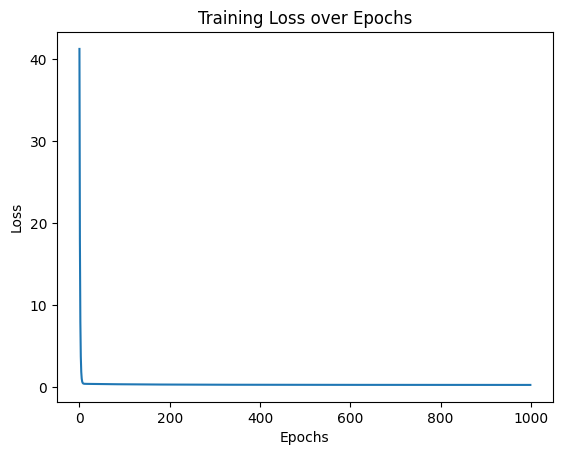

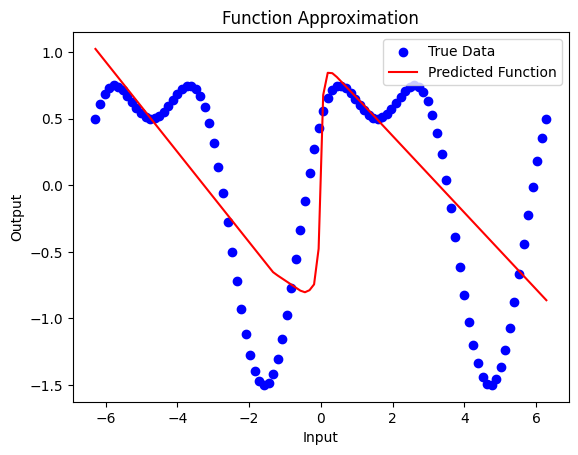

In [4]:
# let's test the shallow neural network with a complex function approximation task with different activation functions

# complex function: f(x) = sin(x) + 0.5 * cos(2x)
x = np.linspace(-2*np.pi, 2*np.pi, 100)
y = np.sin(x) + 0.5 * np.cos(2 * x)

shallow_nn_model = nn(input_dim=1, hidden_dim=100, output_dim=1, n_layers=1, activation_name='ReLU')
losses = shallow_nn_model.train(x.reshape(-1, 1), y.reshape(-1, 1), epochs=1000, learning_rate=0.00001)
shallow_nn_model.plot_loss(losses)
x_range = np.linspace(x.min(), x.max(), 100)
y_pred = np.array([shallow_nn_model.predict(np.array([xi])).squeeze() for xi in x_range])

plt.scatter(x, y, color='blue', label='True Data')
plt.plot(x_range, y_pred, color='red', label='Predicted Function')
plt.title("Function Approximation")
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.show()



# Comparative Study: Activation Functions for Function Approximation

This section systematically compares how well a **neural network (`nn` class, generalized to support `n_layers` hidden layers; this study uses `n_layers=1` to match the original shallow-network comparison)** can approximate a target function when using each of the 10 activation functions defined above:

`ReLU`, `sigmoid`, `tanh`, `leaky_ReLU`, `softmax`, `linear`, `ELU`, `SELU`, `GELU`, `swish`

We run two experiments:

1. **1D function approximation** - target: $f(x) = \sin(x) + 0.5\cos(2x)$
2. **2D function approximation** - target: $f(x, y) = \sin(x)\cos(y)$

For each experiment, every activation function is trained from the **same initial weights** (the `nn` class seeds its weight initialization internally), on the **same data**, with the **same hyperparameters** (hidden units, epochs, learning rate), so that differences in the results are attributable to the choice of activation function rather than to confounding factors.

For each activation we record:
- the training loss curve,
- the final predicted function (visualized against the ground truth),
- the final mean squared error (MSE).


## Setup: activation list and a shared training/evaluation utility

In [ ]:
# All activation functions we will compare
ACTIVATIONS = ['ReLU', 'sigmoid', 'tanh', 'leaky_ReLU', 'softmax', 'linear', 'ELU', 'SELU', 'GELU', 'swish']

def train_and_evaluate(x_train, y_train, input_dim, hidden_dim, epochs, learning_rate, optimization='sgd', n_layers=1):

    results = {}
    for act in ACTIVATIONS:
        model = nn(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=1, n_layers=n_layers, activation_name=act)
        losses = model.train(
            x_train, y_train,
            epochs=epochs,
            learning_rate=learning_rate,
            optimization=optimization,
            verbose=False,
        )
        y_pred = np.array([model.predict(xi).squeeze() for xi in x_train])
        mse = float(np.mean((y_pred.reshape(-1) - y_train.reshape(-1)) ** 2))
        results[act] = {'model': model, 'losses': losses, 'y_pred': y_pred, 'mse': mse}
        final_loss = losses[-1]
        status = 'diverged (NaN)' if np.isnan(final_loss) else f'{final_loss:.5f}'
        print(f"[{act:12s}] final training loss = {status:>16}   final MSE = {mse:.5f}" if not np.isnan(final_loss)
              else f"[{act:12s}] final training loss = {status:>16}")
    return results


## One-dimensional function approximation

**Target function:** $f(x) = \sin(x) + 0.5\cos(2x)$ on $x \in [-2\pi, 2\pi]$ (100 points)

**Model:** `nn(input_dim=1, hidden_dim=64, output_dim=1, n_layers=1)`

**Training:** 1500 epochs, SGD, learning rate = 0.001 (chosen to be small/stable enough that none of the 10 activations diverge, which lets us compare them fairly).

In [6]:
# Target 1D function
x_1d = np.linspace(-2 * np.pi, 2 * np.pi, 100)
y_1d = np.sin(x_1d) + 0.5 * np.cos(2 * x_1d)

HIDDEN_DIM_1D = 64
EPOCHS_1D = 1500
LR_1D = 0.001

results_1d = train_and_evaluate(
    x_1d.reshape(-1, 1), y_1d.reshape(-1, 1),
    input_dim=1, hidden_dim=HIDDEN_DIM_1D,
    epochs=EPOCHS_1D, learning_rate=LR_1D,
)


[ReLU        ] final training loss =          0.09179   final MSE = 0.67540


[sigmoid     ] final training loss =          0.16619   final MSE = 0.17434


[tanh        ] final training loss =          0.06833   final MSE = 0.17735


[leaky_ReLU  ] final training loss =          0.09163   final MSE = 0.67606


[softmax     ] final training loss =          0.16592   final MSE = 0.16532


[linear      ] final training loss =          0.45874   final MSE = 0.69340


[ELU         ] final training loss =          0.02077   final MSE = 0.35487


[SELU        ] final training loss =          0.01280   final MSE = 0.27507


[GELU        ] final training loss =          0.02875   final MSE = 0.28725


[swish       ] final training loss =          0.04292   final MSE = 0.54909


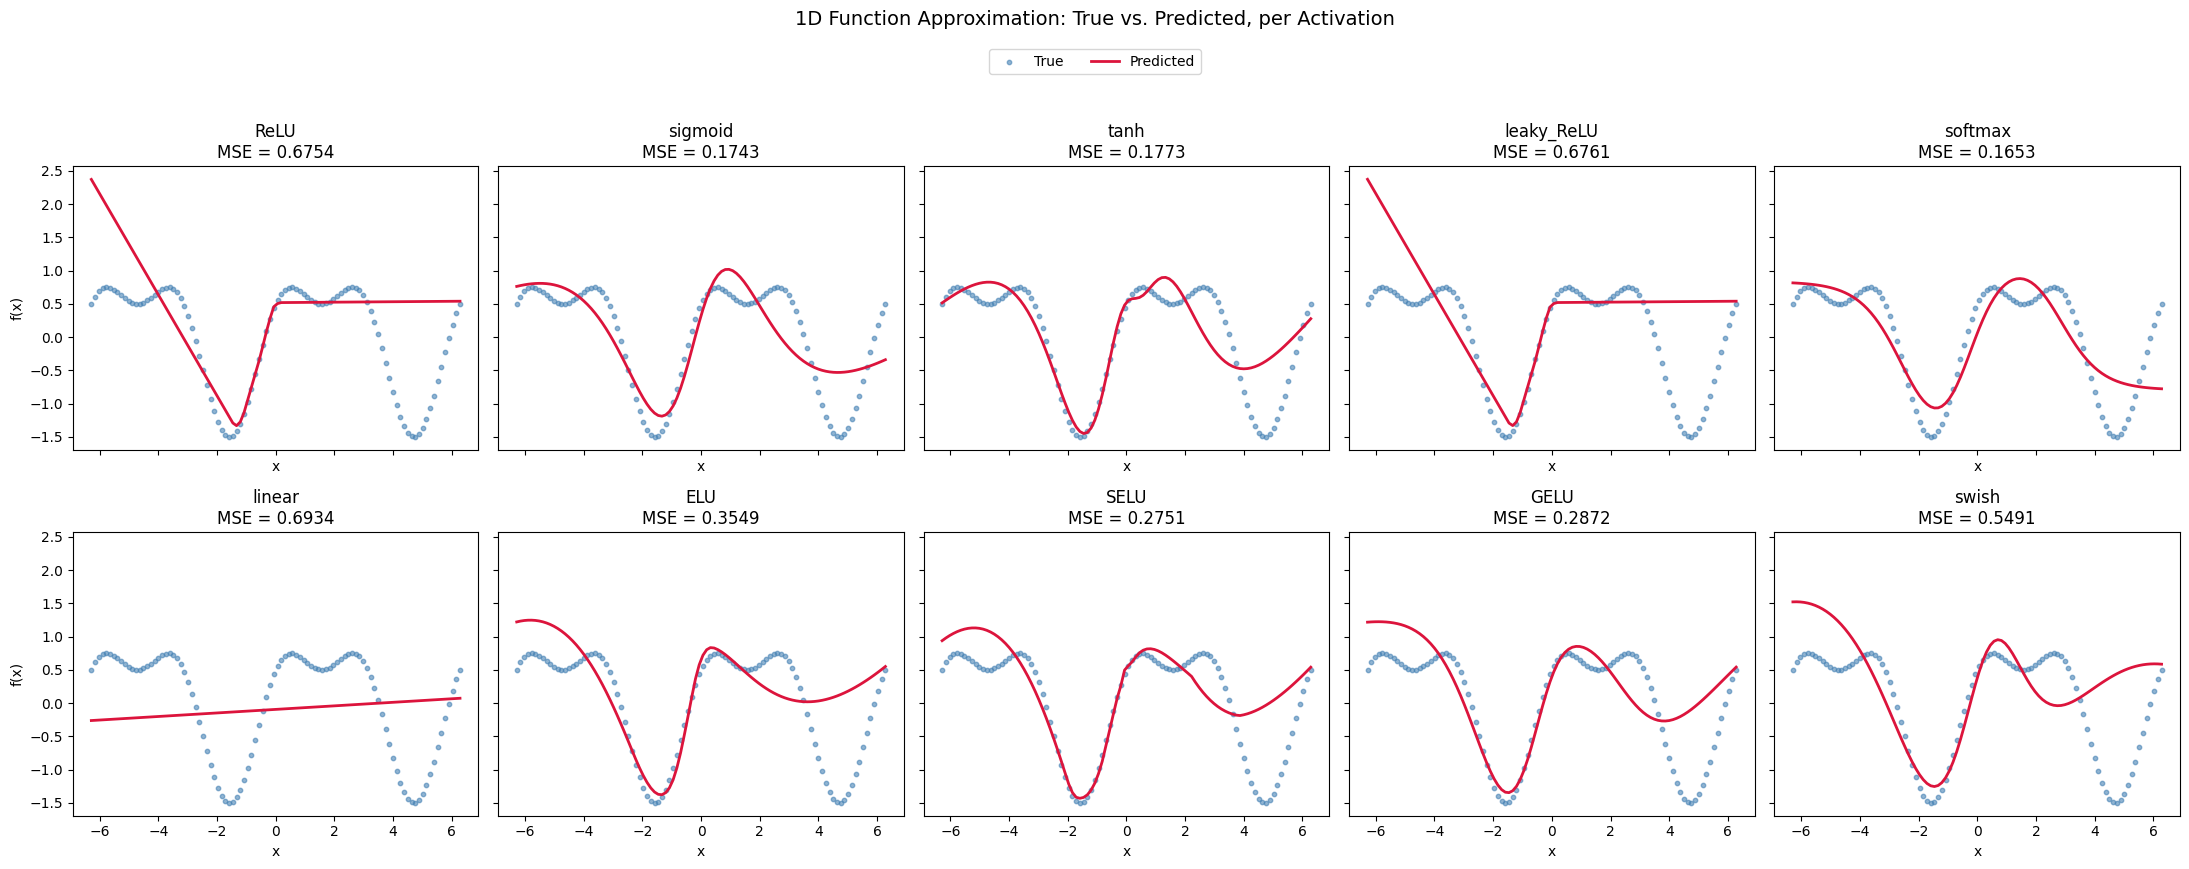

In [7]:
# Grid of true-vs-predicted plots, one subplot per activation
fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, act in zip(axes, ACTIVATIONS):
    res = results_1d[act]
    ax.scatter(x_1d, y_1d, s=10, color='steelblue', label='True', alpha=0.6)
    ax.plot(x_1d, res['y_pred'], color='crimson', linewidth=2, label='Predicted')
    mse_str = 'NaN' if np.isnan(res['mse']) else f"{res['mse']:.4f}"
    ax.set_title(f"{act}\nMSE = {mse_str}")
    ax.set_xlabel('x')

axes[0].set_ylabel('f(x)')
axes[5].set_ylabel('f(x)')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.04))
fig.suptitle('1D Function Approximation: True vs. Predicted, per Activation', y=1.08, fontsize=14)
plt.tight_layout()
plt.show()


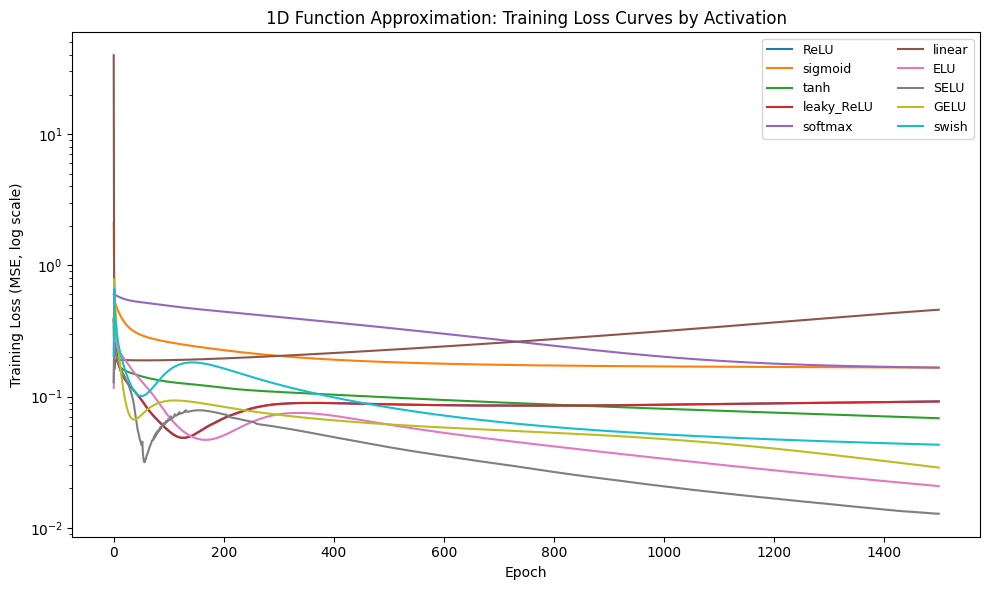

In [8]:
# Training loss curves for all activations, overlaid (log scale)
plt.figure(figsize=(10, 6))
for act in ACTIVATIONS:
    losses = results_1d[act]['losses']
    plt.plot(losses, label=act)

plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Training Loss (MSE, log scale)')
plt.title('1D Function Approximation: Training Loss Curves by Activation')
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


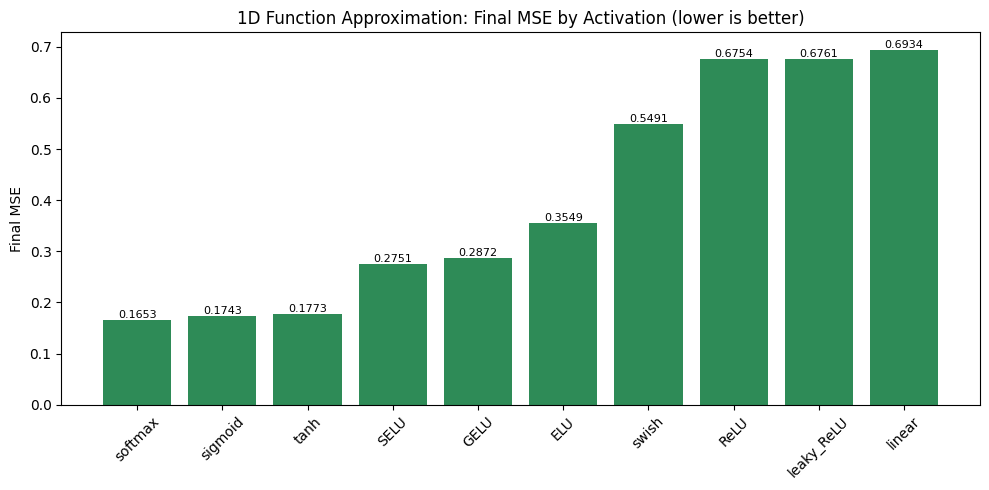

In [9]:
# Final MSE comparison, sorted best -> worst
mse_1d = {act: results_1d[act]['mse'] for act in ACTIVATIONS}
sorted_acts_1d = sorted(mse_1d, key=lambda a: (np.isnan(mse_1d[a]), mse_1d[a]))

plt.figure(figsize=(10, 5))
values = [0 if np.isnan(mse_1d[a]) else mse_1d[a] for a in sorted_acts_1d]
colors = ['gray' if np.isnan(mse_1d[a]) else 'seagreen' for a in sorted_acts_1d]
bars = plt.bar(sorted_acts_1d, values, color=colors)
for bar, act in zip(bars, sorted_acts_1d):
    label = 'NaN' if np.isnan(mse_1d[act]) else f'{mse_1d[act]:.4f}'
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), label,
              ha='center', va='bottom', fontsize=8)

plt.ylabel('Final MSE')
plt.title('1D Function Approximation: Final MSE by Activation (lower is better)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Two-dimensional function approximation

**Target function:** $f(x, y) = \sin(x)\cos(y)$ on $x, y \in [-3, 3]$, sampled on a $15\times15$ grid (225 points)

**Model:** `nn(input_dim=2, hidden_dim=64, output_dim=1, n_layers=1)` - the same class is reused unmodified; it now generalizes to both arbitrary `input_dim` and arbitrary `n_layers`, and trains sample-by-sample on `(input_dim,)`-shaped vectors.

**Training:** 600 epochs, SGD, learning rate = 0.001.

In [ ]:
# Target 2D function
N_GRID = 15
xs_2d = np.linspace(-3, 3, N_GRID)
ys_2d = np.linspace(-3, 3, N_GRID)
XX, YY = np.meshgrid(xs_2d, ys_2d)
ZZ = np.sin(XX) * np.cos(YY)

X_2d = np.stack([XX.ravel(), YY.ravel()], axis=1)   # shape (225, 2)
z_2d = ZZ.ravel() # shape (225,)

HIDDEN_DIM_2D = 64
EPOCHS_2D = 600
LR_2D = 0.001

results_2d = train_and_evaluate(
    X_2d, z_2d.reshape(-1, 1),
    input_dim=2, hidden_dim=HIDDEN_DIM_2D,
    epochs=EPOCHS_2D, learning_rate=LR_2D,
)


[ReLU        ] final training loss =          0.01881   final MSE = 0.02321


[sigmoid     ] final training loss =          0.01294   final MSE = 0.01269


[tanh        ] final training loss =          0.00447   final MSE = 0.00499


[leaky_ReLU  ] final training loss =          0.01882   final MSE = 0.02357


[softmax     ] final training loss =          0.07701   final MSE = 0.07673


[linear      ] final training loss =          0.09881   final MSE = 0.28800


[ELU         ] final training loss =          0.01643   final MSE = 0.03388


[SELU        ] final training loss =          0.01184   final MSE = 0.02164


[GELU        ] final training loss =          0.00998   final MSE = 0.01722


[swish       ] final training loss =          0.01205   final MSE = 0.02458


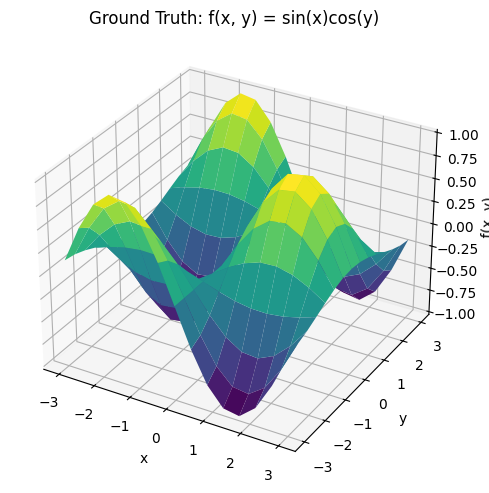

In [11]:
# Ground-truth surface
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(XX, YY, ZZ, cmap='viridis', linewidth=0, antialiased=True)
ax.set_title('Ground Truth: f(x, y) = sin(x)cos(y)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
plt.tight_layout()
plt.show()


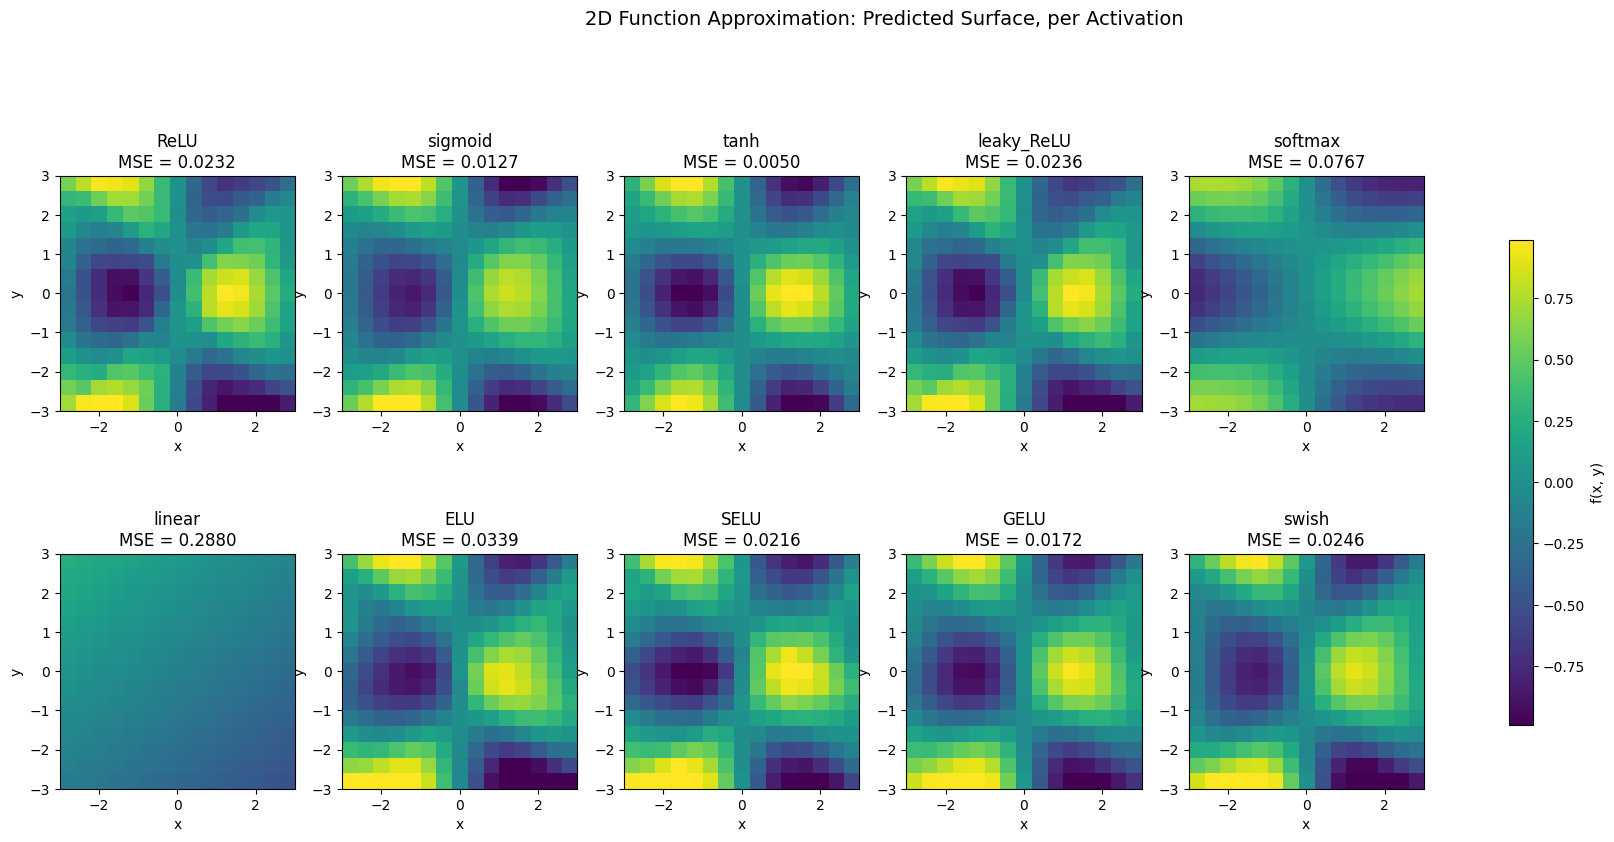

In [12]:
# Predicted surfaces, one heatmap per activation, compared against the true surface
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.ravel()

vmin, vmax = ZZ.min(), ZZ.max()

for ax, act in zip(axes, ACTIVATIONS):
    pred_grid = results_2d[act]['y_pred'].reshape(N_GRID, N_GRID)
    im = ax.imshow(pred_grid, extent=[xs_2d.min(), xs_2d.max(), ys_2d.min(), ys_2d.max()],
                    origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
    mse = results_2d[act]['mse']
    mse_str = 'NaN' if np.isnan(mse) else f'{mse:.4f}'
    ax.set_title(f"{act}\nMSE = {mse_str}")
    ax.set_xlabel('x')
    ax.set_ylabel('y')

fig.colorbar(im, ax=axes.tolist(), shrink=0.7, label='f(x, y)')
fig.suptitle('2D Function Approximation: Predicted Surface, per Activation', y=1.02, fontsize=14)
plt.show()


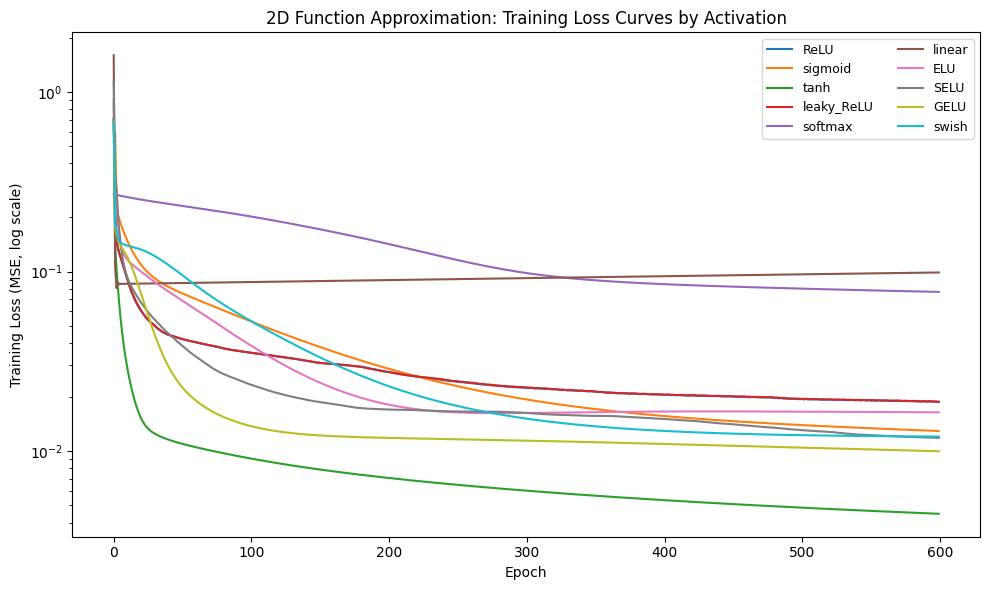

In [13]:
# Training loss curves for all activations, overlaid (log scale)
plt.figure(figsize=(10, 6))
for act in ACTIVATIONS:
    losses = results_2d[act]['losses']
    plt.plot(losses, label=act)

plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Training Loss (MSE, log scale)')
plt.title('2D Function Approximation: Training Loss Curves by Activation')
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


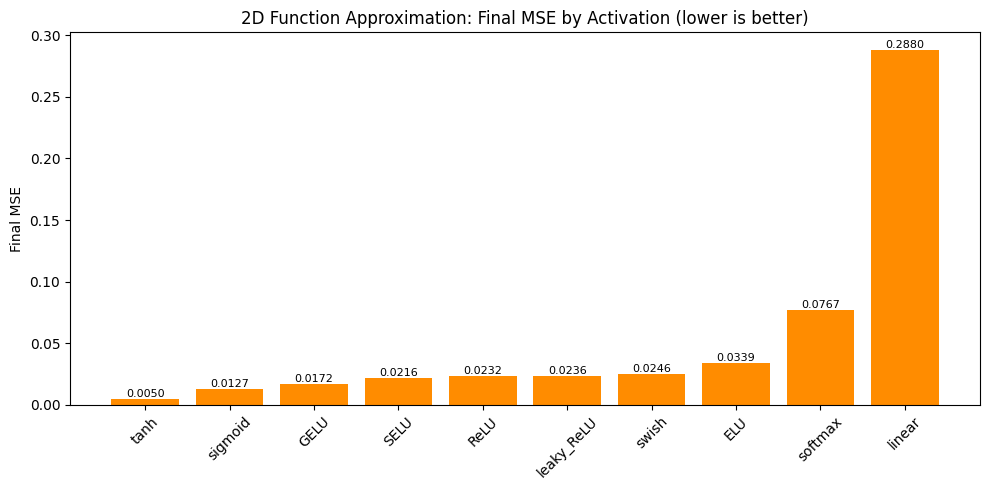

In [14]:
# Final MSE comparison, sorted best -> worst
mse_2d = {act: results_2d[act]['mse'] for act in ACTIVATIONS}
sorted_acts_2d = sorted(mse_2d, key=lambda a: (np.isnan(mse_2d[a]), mse_2d[a]))

plt.figure(figsize=(10, 5))
values = [0 if np.isnan(mse_2d[a]) else mse_2d[a] for a in sorted_acts_2d]
colors = ['gray' if np.isnan(mse_2d[a]) else 'darkorange' for a in sorted_acts_2d]
bars = plt.bar(sorted_acts_2d, values, color=colors)
for bar, act in zip(bars, sorted_acts_2d):
    label = 'NaN' if np.isnan(mse_2d[act]) else f'{mse_2d[act]:.4f}'
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), label,
              ha='center', va='bottom', fontsize=8)

plt.ylabel('Final MSE')
plt.title('2D Function Approximation: Final MSE by Activation (lower is better)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Summary table: 1D vs. 2D performance by activation

In [15]:
header = f"{'Activation':<12} | {'1D MSE':>10} | {'1D rank':>7} | {'2D MSE':>10} | {'2D rank':>7}"
print(header)
print('-' * len(header))

rank_1d = {act: i + 1 for i, act in enumerate(sorted_acts_1d)}
rank_2d = {act: i + 1 for i, act in enumerate(sorted_acts_2d)}

for act in ACTIVATIONS:
    m1 = 'NaN' if np.isnan(mse_1d[act]) else f'{mse_1d[act]:.5f}'
    m2 = 'NaN' if np.isnan(mse_2d[act]) else f'{mse_2d[act]:.5f}'
    print(f"{act:<12} | {m1:>10} | {rank_1d[act]:>7} | {m2:>10} | {rank_2d[act]:>7}")


Activation   |     1D MSE | 1D rank |     2D MSE | 2D rank
----------------------------------------------------------
ReLU         |    0.67540 |       8 |    0.02321 |       5
sigmoid      |    0.17434 |       2 |    0.01269 |       2
tanh         |    0.17735 |       3 |    0.00499 |       1
leaky_ReLU   |    0.67606 |       9 |    0.02357 |       6
softmax      |    0.16532 |       1 |    0.07673 |       9
linear       |    0.69340 |      10 |    0.28800 |      10
ELU          |    0.35487 |       6 |    0.03388 |       8
SELU         |    0.27507 |       4 |    0.02164 |       4
GELU         |    0.28725 |       5 |    0.01722 |       3
swish        |    0.54909 |       7 |    0.02458 |       7


## Width study: how hidden-layer size affects nonlinearity approximation

The comparisons above all use a fixed hidden layer of 64 neurons. Here we hold everything else constant (`n_layers=1`, activation = `tanh`, the best all-round performer from Section 4) and instead vary **`hidden_dim`** the number of neurons in the single hidden layer to see how the network's capacity to approximate a nonlinear function grows with width.

To make the effect clearly visible, we switch to a **higher-frequency target function** than the one used earlier: `f(x) = sin(2x) + 0.3·sin(5x)`. This has more curvature/oscillation than `sin(x) + 0.5·cos(2x)`, so a network with very few neurons should visibly fail to capture it, while a wider network should trace it much more closely (universal approximation: more neurons = more piecewise "basis functions" to combine).

In [ ]:
# Target function for the width study higher frequency than the earlier 1D task, so the effect of adding hidden neurons is clearly visible
x_w = np.linspace(-2 * np.pi, 2 * np.pi, 150)
y_w = np.sin(2 * x_w) + 0.3 * np.sin(5 * x_w)

HIDDEN_DIMS_WIDTH_STUDY = [1, 2, 4, 8, 16, 32]
EPOCHS_WIDTH = 4000
LR_WIDTH = 0.001
WIDTH_STUDY_ACTIVATION = 'tanh'

results_width = {}
for h in HIDDEN_DIMS_WIDTH_STUDY:
    model = nn(input_dim=1, hidden_dim=h, output_dim=1, n_layers=1, activation_name=WIDTH_STUDY_ACTIVATION)
    losses = model.train(x_w.reshape(-1, 1), y_w.reshape(-1, 1), epochs=EPOCHS_WIDTH,
                         learning_rate=LR_WIDTH, verbose=False)
    y_pred = np.array([model.predict(xi).squeeze() for xi in x_w.reshape(-1, 1)])
    mse = np.mean((y_pred - y_w) ** 2)
    results_width[h] = {'y_pred': y_pred, 'losses': losses, 'mse': mse}
    print(f"hidden_dim={h:>3} | final MSE = {mse:.5f}")


hidden_dim=  1 | final MSE = 0.51996


hidden_dim=  2 | final MSE = 0.40031


hidden_dim=  4 | final MSE = 0.24889


hidden_dim=  8 | final MSE = 0.23295


hidden_dim= 16 | final MSE = 0.08543


hidden_dim= 32 | final MSE = 0.06674


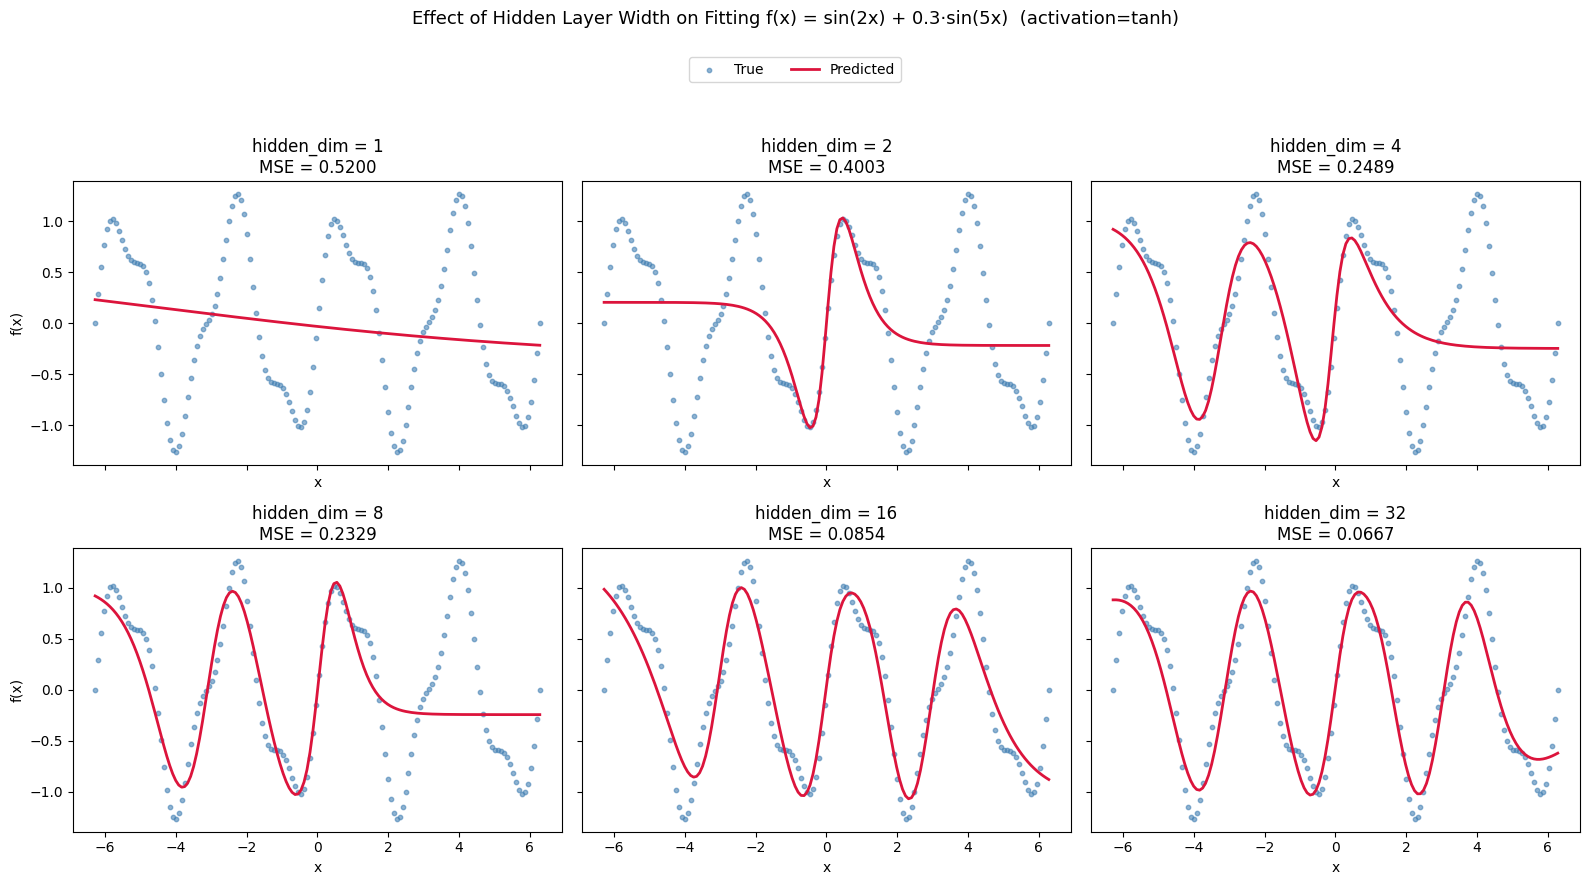

In [18]:
# Grid of true-vs-predicted plots, one subplot per hidden layer width
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, h in zip(axes, HIDDEN_DIMS_WIDTH_STUDY):
    res = results_width[h]
    ax.scatter(x_w, y_w, s=10, color='steelblue', label='True', alpha=0.6)
    ax.plot(x_w, res['y_pred'], color='crimson', linewidth=2, label='Predicted')
    ax.set_title(f"hidden_dim = {h}\nMSE = {res['mse']:.4f}")
    ax.set_xlabel('x')

axes[0].set_ylabel('f(x)')
axes[3].set_ylabel('f(x)')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.05))
fig.suptitle(f'Effect of Hidden Layer Width on Fitting f(x) = sin(2x) + 0.3\u00b7sin(5x)  (activation={WIDTH_STUDY_ACTIVATION})',
             y=1.1, fontsize=13)
plt.tight_layout()
plt.show()


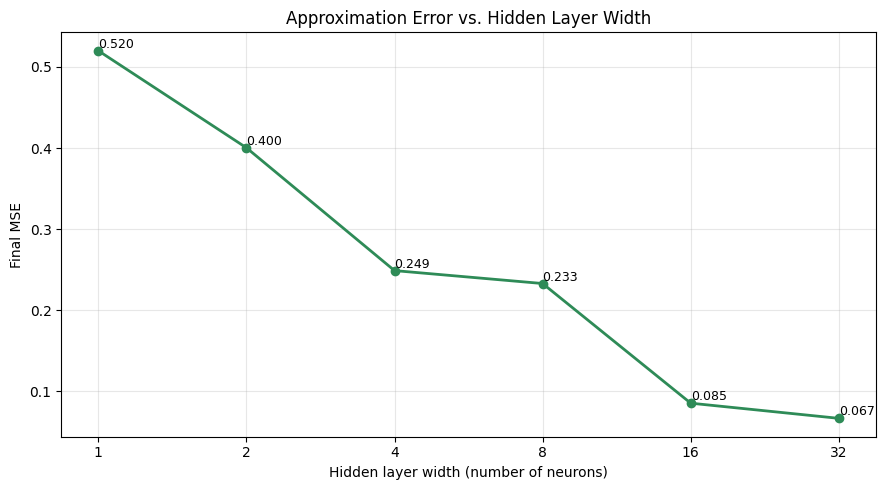

In [19]:
# Final MSE vs. hidden layer width (log-x, since widths double each step)
widths = HIDDEN_DIMS_WIDTH_STUDY
mses = [results_width[h]['mse'] for h in widths]

plt.figure(figsize=(9, 5))
plt.plot(widths, mses, marker='o', linewidth=2, color='seagreen')
for h, m in zip(widths, mses):
    plt.text(h, m, f'{m:.3f}', ha='left', va='bottom', fontsize=9)
plt.xscale('log', base=2)
plt.xticks(widths, [str(w) for w in widths])
plt.xlabel('Hidden layer width (number of neurons)')
plt.ylabel('Final MSE')
plt.title('Approximation Error vs. Hidden Layer Width')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Observations: width study

- **Error drops sharply as width increases from 1 to 32 neurons.** A single hidden neuron can only bend the input through one `tanh` "kink", so it produces close to a straight-line fit; by 32 neurons the network closely tracks both the slow and fast oscillations of the target function.
- **Returns diminish rather than grow forever.** The MSE drop from 1->4 neurons is much larger than the drop from 1->32 neurons consistent with the universal approximation theorem, where each additional neuron adds one more basis function to combine, but the *marginal* benefit shrinks once the network already has enough capacity to represent the target's dominant frequencies.
- **Wider isn't automatically better in practice.** Under this notebook's plain per-sample SGD with a fixed learning rate and a fixed epoch budget, layers much wider than ~32 neurons (e.g. 64, 128) need proportionally *more* training epochs to converge with the same epoch budget they can score worse than a 32-neuron layer simply because they haven't finished converging yet, not because they lack representational capacity. This is an optimization-time effect, not a capacity effect.
